In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [87]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

In [88]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (691369, 14)
Test shape: (296302, 13)


In [89]:
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [90]:
test.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


In [91]:
train.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [92]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [93]:
train.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183466,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [94]:
train["addicted_label"].value_counts()

,count
addicted_label,
1,490474
0,200895


In [95]:
train["addicted_label"].value_counts(normalize=True)

,proportion
addicted_label,
1,0.709424
0,0.290576


In [96]:
train.isnull().sum()

,0
id,0
age,28929
daily_screen_time_hours,95854
social_media_hours,133995
gaming_hours,126821
work_study_hours,51518
sleep_hours,44480
notifications_per_day,67584
app_opens_per_day,80710
weekend_screen_time,112063


In [97]:
print(train["gender"].value_counts(dropna=False))

gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64


In [98]:
print(train["stress_level"].value_counts(dropna=False))

stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64


In [99]:
print(train["academic_work_impact"].value_counts(dropna=False))

academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64


In [100]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


In [101]:
print("Duplicate IDs:", train["id"].duplicated().sum())

Duplicate IDs: 0


In [102]:
print("Train ID range:", train["id"].min(), train["id"].max())
print("Test ID range:", test["id"].min(), test["id"].max())

Train ID range: 0 691368
Test ID range: 691369 987670


In [103]:
numerical_cols = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

categorical_cols = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

target = "addicted_label"

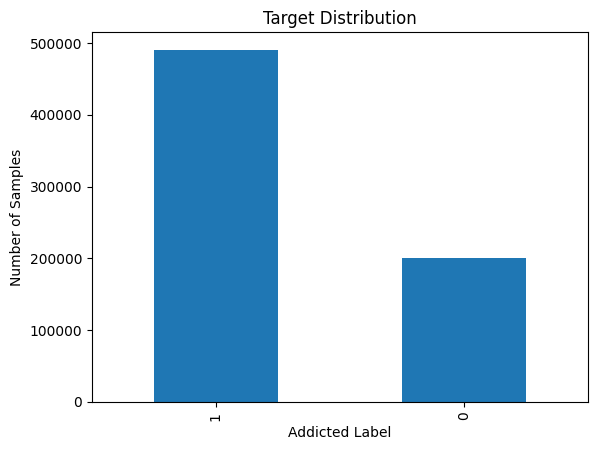

In [104]:
train["addicted_label"].value_counts().plot(
    kind="bar"
)

plt.title("Target Distribution")
plt.xlabel("Addicted Label")
plt.ylabel("Number of Samples")
plt.show()

In [105]:
train[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


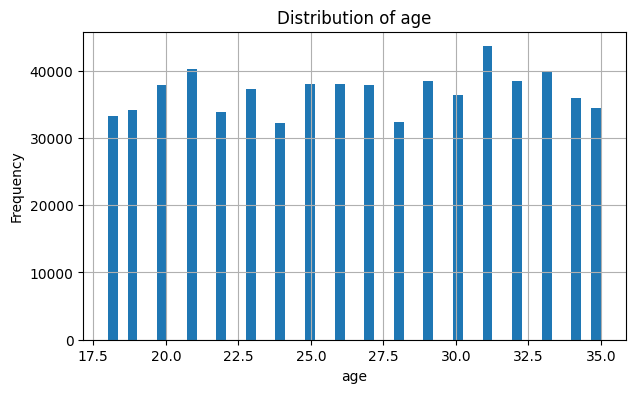

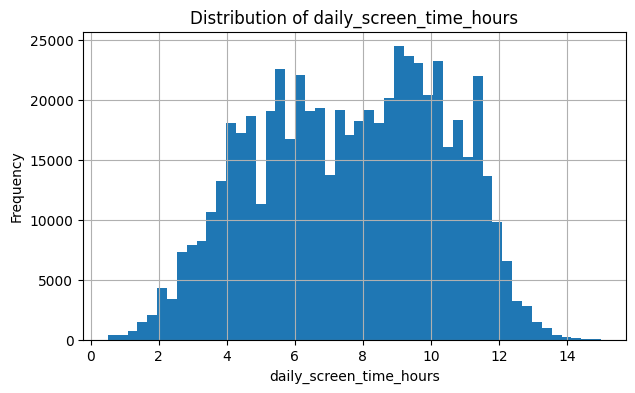

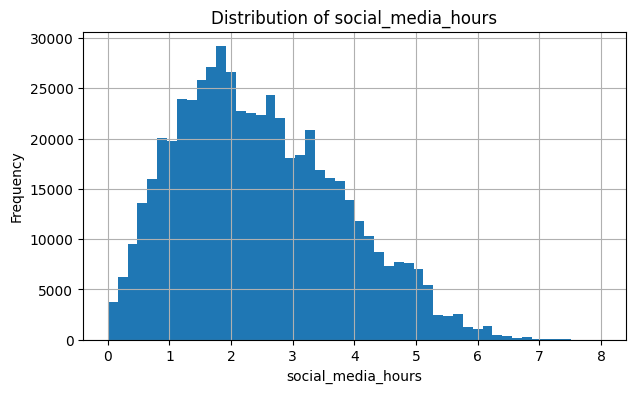

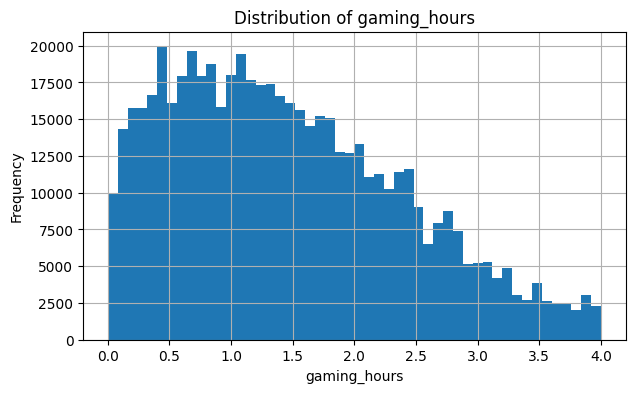

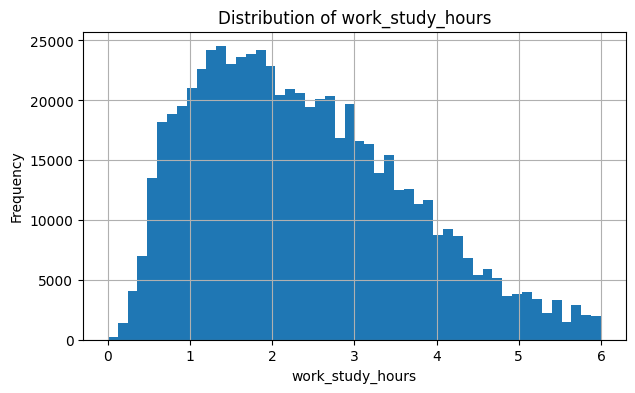

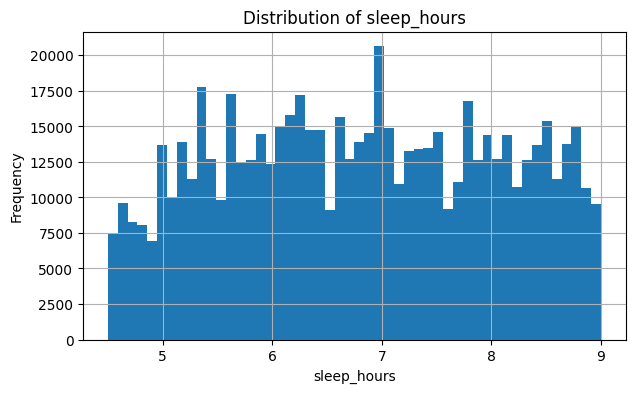

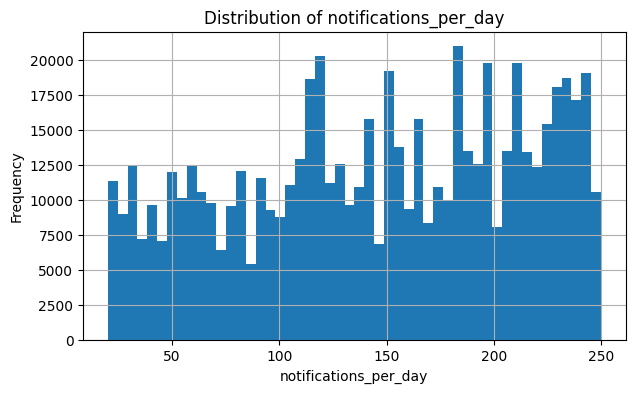

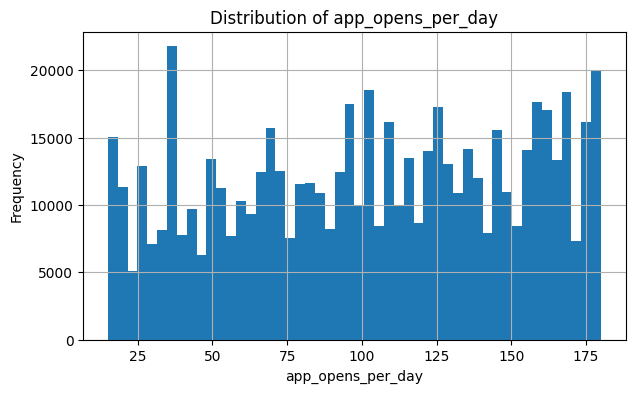

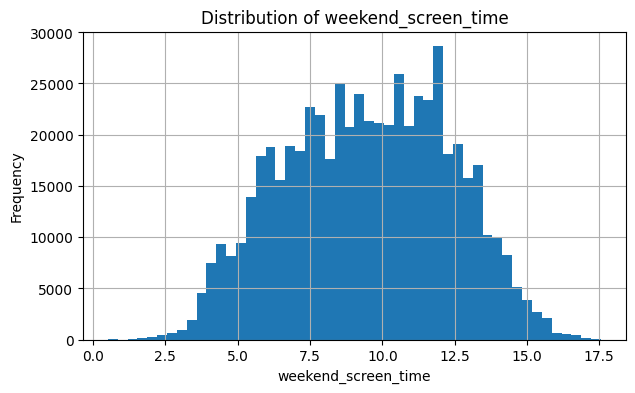

In [106]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    train[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [107]:
train.groupby("addicted_label")[
    numerical_cols
].mean().T

addicted_label,0,1
age,26.582864,26.628749
daily_screen_time_hours,5.042929,8.706523
social_media_hours,1.376144,2.919495
gaming_hours,1.159677,1.582119
work_study_hours,1.872582,2.569566
sleep_hours,6.722321,6.837970
notifications_per_day,147.087661,145.406142
app_opens_per_day,97.871440,104.592844
weekend_screen_time,6.848920,10.558729


In [108]:
train.groupby("addicted_label")[
    numerical_cols
].median().T

addicted_label,0,1
age,27.00,27.00
daily_screen_time_hours,5.04,9.07
social_media_hours,1.29,2.82
gaming_hours,1.07,1.48
work_study_hours,1.75,2.47
sleep_hours,6.72,6.84
notifications_per_day,154.00,150.00
app_opens_per_day,99.00,109.00
weekend_screen_time,6.82,10.79


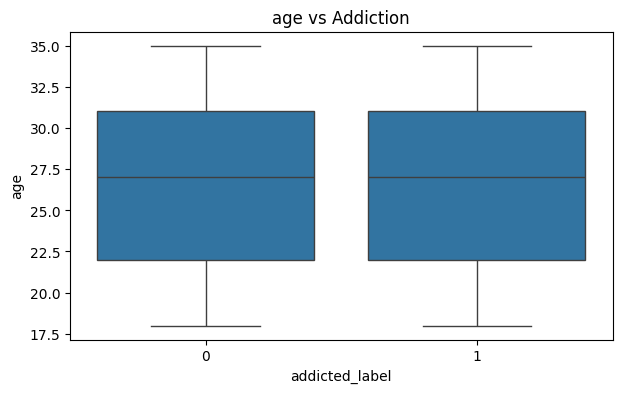

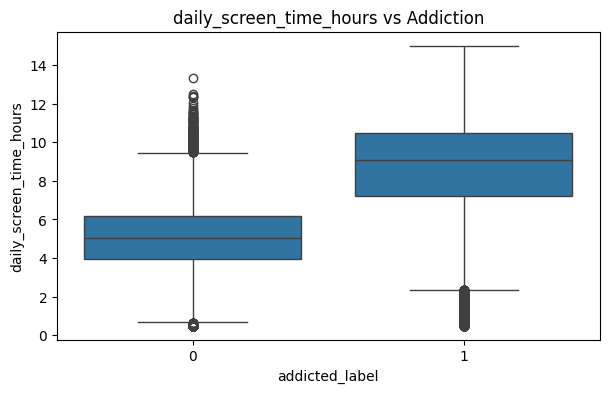

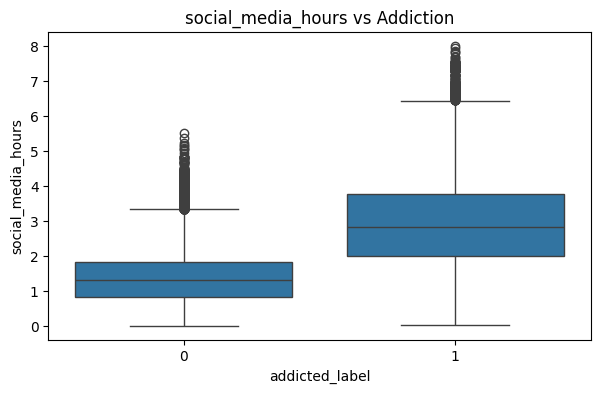

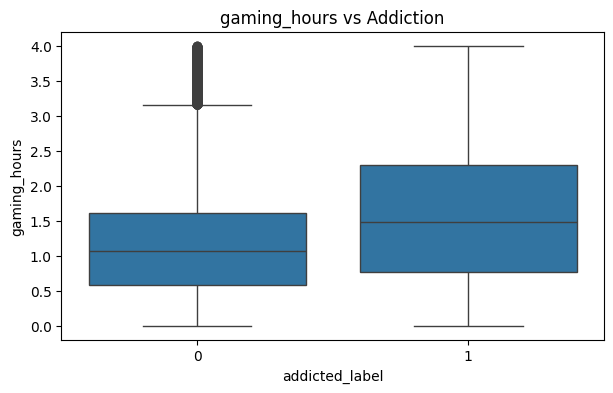

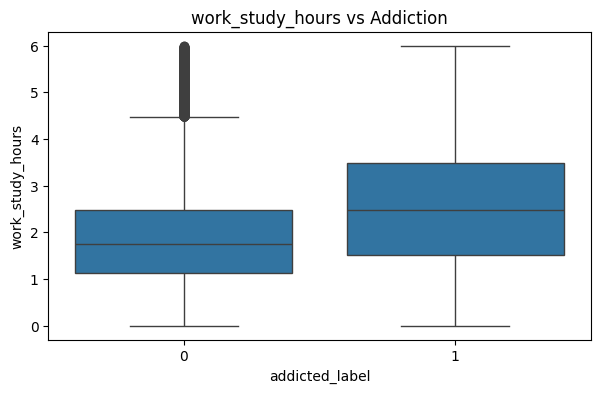

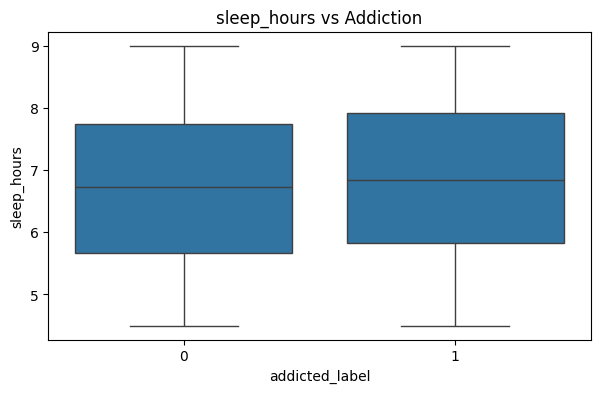

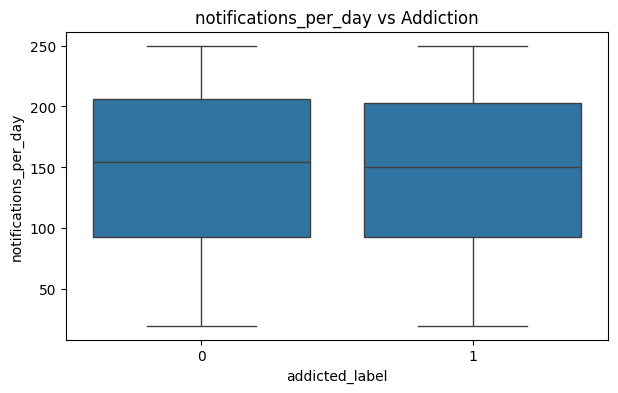

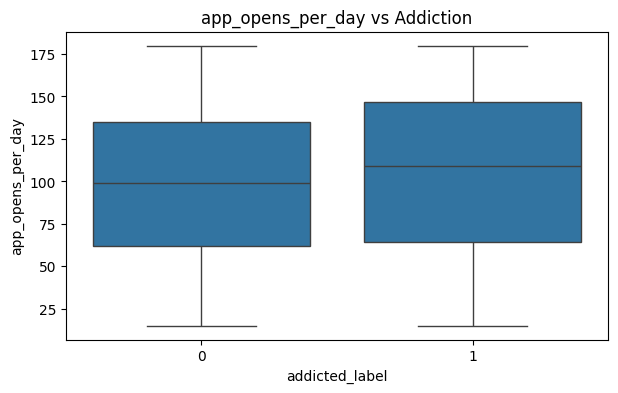

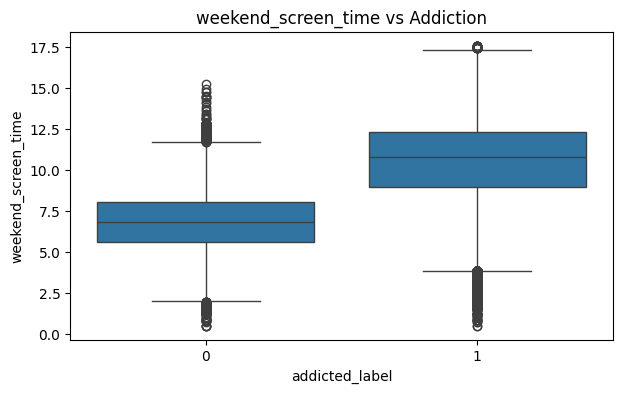

In [109]:

for col in numerical_cols:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=train,
        x="addicted_label",
        y=col
    )

    plt.title(f"{col} vs Addiction")
    plt.show()

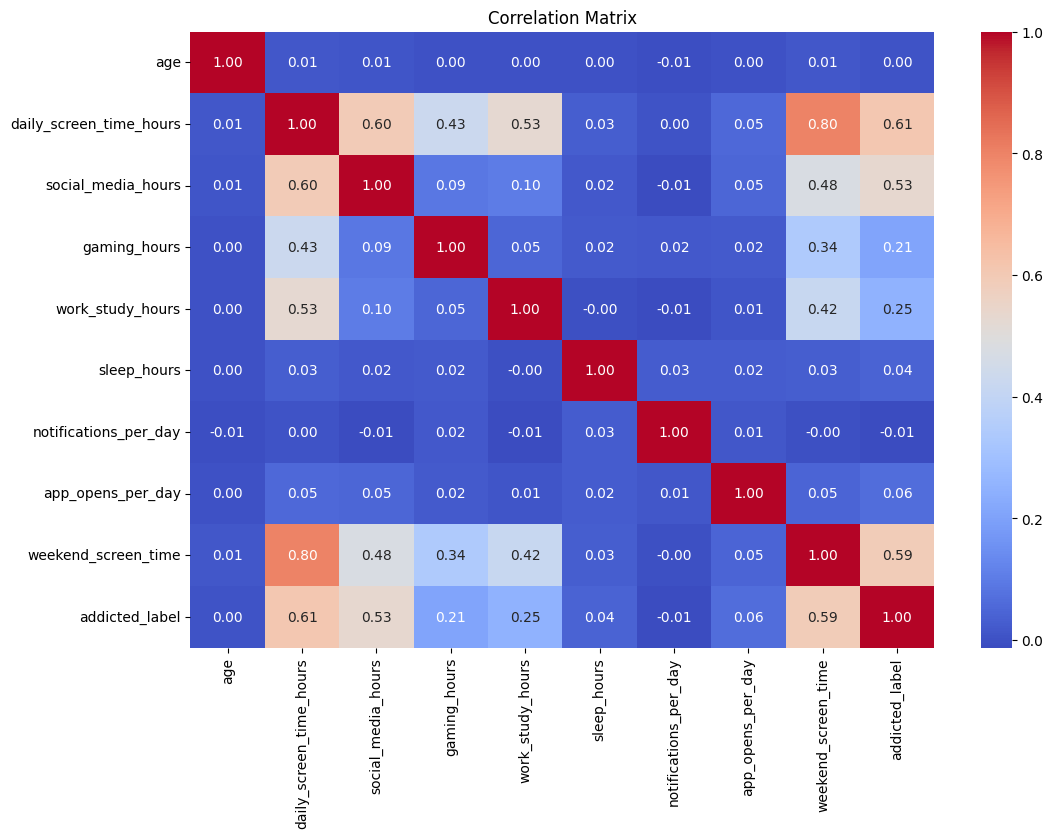

In [110]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    train[numerical_cols + [target]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [111]:
pd.crosstab(
    train["gender"],
    train["addicted_label"],
    normalize="index"
)

addicted_label,0,1
gender,,
Female,0.296162,0.703838
Male,0.276802,0.723198
Other,0.298980,0.701020


In [112]:
pd.crosstab(
    train["stress_level"],
    train["addicted_label"],
    normalize="index"
)

addicted_label,0,1
stress_level,,
High,0.288569,0.711431
Low,0.288840,0.711160
Medium,0.294337,0.705663


In [113]:
pd.crosstab(
    train["academic_work_impact"],
    train["addicted_label"],
    normalize="index"
)

addicted_label,0,1
academic_work_impact,,
No,0.288971,0.711029
Yes,0.292117,0.707883


In [114]:
missing_summary = pd.DataFrame({
    "missing_count": train.isnull().sum(),
    "missing_percent": train.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

missing_summary

,missing_count,missing_percent
social_media_hours,133995,19.381112
gaming_hours,126821,18.343461
weekend_screen_time,112063,16.208855
daily_screen_time_hours,95854,13.864376
app_opens_per_day,80710,11.673940
notifications_per_day,67584,9.775388
stress_level,55148,7.976638
work_study_hours,51518,7.451592
sleep_hours,44480,6.433612
academic_work_impact,44224,6.396584


In [115]:
for col in numerical_cols:
    train[f"{col}_missing"] = train[col].isna().astype(int)

train.groupby("social_media_hours_missing")[
    "addicted_label"
].mean()

,addicted_label
social_media_hours_missing,
0,0.709427
1,0.709415


In [116]:
for col in numerical_cols:
    missing_rate = train.groupby(
        train[col].isna()
    )["addicted_label"].mean()

    print("\n", col)
    print(missing_rate)


 age
age
False    0.709251
True     0.713402
Name: addicted_label, dtype: float64

 daily_screen_time_hours
daily_screen_time_hours
False    0.709122
True     0.711301
Name: addicted_label, dtype: float64

 social_media_hours
social_media_hours
False    0.709427
True     0.709415
Name: addicted_label, dtype: float64

 gaming_hours
gaming_hours
False    0.709182
True     0.710505
Name: addicted_label, dtype: float64

 work_study_hours
work_study_hours
False    0.709326
True     0.710645
Name: addicted_label, dtype: float64

 sleep_hours
sleep_hours
False    0.709153
True     0.713377
Name: addicted_label, dtype: float64

 notifications_per_day
notifications_per_day
False    0.709336
True     0.710242
Name: addicted_label, dtype: float64

 app_opens_per_day
app_opens_per_day
False    0.708980
True     0.712787
Name: addicted_label, dtype: float64

 weekend_screen_time
weekend_screen_time
False    0.709187
True     0.710654
Name: addicted_label, dtype: float64


In [117]:
print(train["id"].describe())
print(test["id"].describe())

count    691369.000000
mean     345684.000000
std      199581.183466
min           0.000000
25%      172842.000000
50%      345684.000000
75%      518526.000000
max      691368.000000
Name: id, dtype: float64
count    296302.000000
mean     839519.500000
std       85535.164068
min      691369.000000
25%      765444.250000
50%      839519.500000
75%      913594.750000
max      987670.000000
Name: id, dtype: float64


In [118]:
train.groupby(
    pd.qcut(train["id"], 10)
)["addicted_label"].mean()

,addicted_label
id,
"(-0.001, 69136.8]",0.707060
"(69136.8, 138273.6]",0.708781
"(138273.6, 207410.4]",0.711197
"(207410.4, 276547.2]",0.710054
"(276547.2, 345684.0]",0.709533
"(345684.0, 414820.8]",0.706998
"(414820.8, 483957.6]",0.710835
"(483957.6, 553094.4]",0.709201
"(553094.4, 622231.2]",0.710936


In [119]:
train[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


In [120]:
train.groupby("addicted_label")[numerical_cols].mean().T

addicted_label,0,1
age,26.582864,26.628749
daily_screen_time_hours,5.042929,8.706523
social_media_hours,1.376144,2.919495
gaming_hours,1.159677,1.582119
work_study_hours,1.872582,2.569566
sleep_hours,6.722321,6.837970
notifications_per_day,147.087661,145.406142
app_opens_per_day,97.871440,104.592844
weekend_screen_time,6.848920,10.558729


In [121]:
train.groupby("addicted_label")[numerical_cols].median().T

addicted_label,0,1
age,27.00,27.00
daily_screen_time_hours,5.04,9.07
social_media_hours,1.29,2.82
gaming_hours,1.07,1.48
work_study_hours,1.75,2.47
sleep_hours,6.72,6.84
notifications_per_day,154.00,150.00
app_opens_per_day,99.00,109.00
weekend_screen_time,6.82,10.79


In [122]:
for col in categorical_cols:
    print("\n================", col, "================")
    print(
        pd.crosstab(
            train[col],
            train["addicted_label"],
            normalize="index"
        )
    )


================ gender ================
addicted_label         0         1
gender                            
Female          0.296162  0.703838
Male            0.276802  0.723198
Other           0.298980  0.701020

================ stress_level ================
addicted_label         0         1
stress_level                      
High            0.288569  0.711431
Low             0.288840  0.711160
Medium          0.294337  0.705663

================ academic_work_impact ================
addicted_label               0         1
academic_work_impact                    
No                    0.288971  0.711029
Yes                   0.292117  0.707883


In [123]:
missing_summary = pd.DataFrame({
    "missing_count": train.isnull().sum(),
    "missing_percent": train.isnull().mean() * 100
})

missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
social_media_hours,133995,19.381112
gaming_hours,126821,18.343461
weekend_screen_time,112063,16.208855
daily_screen_time_hours,95854,13.864376
app_opens_per_day,80710,11.673940
notifications_per_day,67584,9.775388
stress_level,55148,7.976638
work_study_hours,51518,7.451592
sleep_hours,44480,6.433612
academic_work_impact,44224,6.396584


In [124]:
for col in numerical_cols:
    missing_rate = train.groupby(
        train[col].isna()
    )["addicted_label"].mean()

    print("\n", col)
    print(missing_rate)


 age
age
False    0.709251
True     0.713402
Name: addicted_label, dtype: float64

 daily_screen_time_hours
daily_screen_time_hours
False    0.709122
True     0.711301
Name: addicted_label, dtype: float64

 social_media_hours
social_media_hours
False    0.709427
True     0.709415
Name: addicted_label, dtype: float64

 gaming_hours
gaming_hours
False    0.709182
True     0.710505
Name: addicted_label, dtype: float64

 work_study_hours
work_study_hours
False    0.709326
True     0.710645
Name: addicted_label, dtype: float64

 sleep_hours
sleep_hours
False    0.709153
True     0.713377
Name: addicted_label, dtype: float64

 notifications_per_day
notifications_per_day
False    0.709336
True     0.710242
Name: addicted_label, dtype: float64

 app_opens_per_day
app_opens_per_day
False    0.708980
True     0.712787
Name: addicted_label, dtype: float64

 weekend_screen_time
weekend_screen_time
False    0.709187
True     0.710654
Name: addicted_label, dtype: float64


In [125]:
print("Duplicate rows:", train.duplicated().sum())
print("Duplicate test rows:", test.duplicated().sum())

Duplicate rows: 0
Duplicate test rows: 0


In [126]:
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,...,addicted_label,age_missing,daily_screen_time_hours_missing,social_media_hours_missing,gaming_hours_missing,work_study_hours_missing,sleep_hours_missing,notifications_per_day_missing,app_opens_per_day_missing,weekend_screen_time_missing
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,...,1,0,1,0,0,0,0,0,0,0
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,...,0,0,0,0,1,0,0,0,0,1
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,...,0,0,0,1,1,1,0,0,0,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,...,1,0,0,0,0,0,0,0,0,0
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,...,1,0,0,0,0,0,0,1,1,0


In [127]:
print("Duplicate train IDs:", train["id"].duplicated().sum())
print("Duplicate test IDs:", test["id"].duplicated().sum())

Duplicate train IDs: 0
Duplicate test IDs: 0


In [128]:
comparison = pd.DataFrame({
    "train_mean": train[numerical_cols].mean(),
    "test_mean": test[numerical_cols].mean(),
    "train_missing_%": train[numerical_cols].isna().mean() * 100,
    "test_missing_%": test[numerical_cols].isna().mean() * 100
})

comparison

,train_mean,test_mean,train_missing_%,test_missing_%
age,26.615408,26.608689,4.184307,5.783964
daily_screen_time_hours,7.640865,7.640771,13.864376,11.065737
social_media_hours,2.471038,2.471224,19.381112,15.996180
gaming_hours,1.459265,1.457668,18.343461,20.053864
work_study_hours,2.366971,2.365962,7.451592,9.374557
sleep_hours,6.804334,6.801704,6.433612,7.578417
notifications_per_day,145.894900,145.748066,9.775388,11.549365
app_opens_per_day,102.636781,102.656216,11.673940,8.675271
weekend_screen_time,9.479866,9.474575,16.208855,17.109908


In [129]:
for col in categorical_cols:
    print("\n================", col, "================")

    print("TRAIN")
    print(train[col].value_counts(normalize=True, dropna=False))

    print("\nTEST")
    print(test[col].value_counts(normalize=True, dropna=False))


================ gender ================
TRAIN
gender
Male      0.323506
Female    0.320516
Other     0.313983
NaN       0.041995
Name: proportion, dtype: float64

TEST
gender
Male      0.321824
Female    0.318239
Other     0.311972
NaN       0.047965
Name: proportion, dtype: float64

================ stress_level ================
TRAIN
stress_level
High      0.319472
Low       0.300538
Medium    0.300223
NaN       0.079766
Name: proportion, dtype: float64

TEST
stress_level
High      0.322718
Low       0.306262
Medium    0.304784
NaN       0.066236
Name: proportion, dtype: float64

================ academic_work_impact ================
TRAIN
academic_work_impact
Yes    0.478133
No     0.457902
NaN    0.063966
Name: proportion, dtype: float64

TEST
academic_work_impact
Yes    0.468083
No     0.445110
NaN    0.086807
Name: proportion, dtype: float64


In [130]:
comparison = pd.DataFrame({
    "train_mean": train[numerical_cols].mean(),
    "test_mean": test[numerical_cols].mean(),
    "train_missing_%": train[numerical_cols].isna().mean() * 100,
    "test_missing_%": test[numerical_cols].isna().mean() * 100
})

print(comparison)

                         train_mean   test_mean  train_missing_%  \
age                       26.615408   26.608689         4.184307   
daily_screen_time_hours    7.640865    7.640771        13.864376   
social_media_hours         2.471038    2.471224        19.381112   
gaming_hours               1.459265    1.457668        18.343461   
work_study_hours           2.366971    2.365962         7.451592   
sleep_hours                6.804334    6.801704         6.433612   
notifications_per_day    145.894900  145.748066         9.775388   
app_opens_per_day        102.636781  102.656216        11.673940   
weekend_screen_time        9.479866    9.474575        16.208855   

                         test_missing_%  
age                            5.783964  
daily_screen_time_hours       11.065737  
social_media_hours            15.996180  
gaming_hours                  20.053864  
work_study_hours               9.374557  
sleep_hours                    7.578417  
notifications_per_day    

In [131]:
for col in numerical_cols:
    result = train.groupby(
        train[col].isna()
    )["addicted_label"].mean()

    print(f"\n{col}")
    print(result)


age
age
False    0.709251
True     0.713402
Name: addicted_label, dtype: float64

daily_screen_time_hours
daily_screen_time_hours
False    0.709122
True     0.711301
Name: addicted_label, dtype: float64

social_media_hours
social_media_hours
False    0.709427
True     0.709415
Name: addicted_label, dtype: float64

gaming_hours
gaming_hours
False    0.709182
True     0.710505
Name: addicted_label, dtype: float64

work_study_hours
work_study_hours
False    0.709326
True     0.710645
Name: addicted_label, dtype: float64

sleep_hours
sleep_hours
False    0.709153
True     0.713377
Name: addicted_label, dtype: float64

notifications_per_day
notifications_per_day
False    0.709336
True     0.710242
Name: addicted_label, dtype: float64

app_opens_per_day
app_opens_per_day
False    0.708980
True     0.712787
Name: addicted_label, dtype: float64

weekend_screen_time
weekend_screen_time
False    0.709187
True     0.710654
Name: addicted_label, dtype: float64


In [132]:
train_fe = train.copy()
test_fe = test.copy()

In [133]:
train_fe["entertainment_hours"] = (
    train_fe["social_media_hours"].fillna(0)
    + train_fe["gaming_hours"].fillna(0)
)

test_fe["entertainment_hours"] = (
    test_fe["social_media_hours"].fillna(0)
    + test_fe["gaming_hours"].fillna(0)
)

In [134]:
train_fe["entertainment_ratio"] = (
    train_fe["entertainment_hours"]
    / (train_fe["daily_screen_time_hours"] + 1e-6)
)

test_fe["entertainment_ratio"] = (
    test_fe["entertainment_hours"]
    / (test_fe["daily_screen_time_hours"] + 1e-6)
)

In [135]:
train_fe["social_media_ratio"] = (
    train_fe["social_media_hours"]
    / (train_fe["daily_screen_time_hours"] + 1e-6)
)

test_fe["social_media_ratio"] = (
    test_fe["social_media_hours"]
    / (test_fe["daily_screen_time_hours"] + 1e-6)
)

In [136]:
train_fe["gaming_ratio"] = (
    train_fe["gaming_hours"]
    / (train_fe["daily_screen_time_hours"] + 1e-6)
)

test_fe["gaming_ratio"] = (
    test_fe["gaming_hours"]
    / (test_fe["daily_screen_time_hours"] + 1e-6)
)

In [137]:
train_fe["work_study_ratio"] = (
    train_fe["work_study_hours"]
    / (train_fe["daily_screen_time_hours"] + 1e-6)
)

test_fe["work_study_ratio"] = (
    test_fe["work_study_hours"]
    / (test_fe["daily_screen_time_hours"] + 1e-6)
)

In [138]:
train_fe["sleep_screen_ratio"] = (
    train_fe["sleep_hours"]
    / (train_fe["daily_screen_time_hours"] + 1e-6)
)

test_fe["sleep_screen_ratio"] = (
    test_fe["sleep_hours"]
    / (test_fe["daily_screen_time_hours"] + 1e-6)
)

In [139]:
train_fe["screen_sleep_ratio"] = (
    train_fe["daily_screen_time_hours"]
    / (train_fe["sleep_hours"] + 1e-6)
)

test_fe["screen_sleep_ratio"] = (
    test_fe["daily_screen_time_hours"]
    / (test_fe["sleep_hours"] + 1e-6)
)

In [140]:
train_fe["weekend_screen_diff"] = (
    train_fe["weekend_screen_time"]
    - train_fe["daily_screen_time_hours"]
)

test_fe["weekend_screen_diff"] = (
    test_fe["weekend_screen_time"]
    - test_fe["daily_screen_time_hours"]
)

In [141]:
train_fe["weekend_screen_ratio"] = (
    train_fe["weekend_screen_time"]
    / (train_fe["daily_screen_time_hours"] + 1e-6)
)

test_fe["weekend_screen_ratio"] = (
    test_fe["weekend_screen_time"]
    / (test_fe["daily_screen_time_hours"] + 1e-6)
)

In [142]:
train_fe["app_opens_per_screen_hour"] = (
    train_fe["app_opens_per_day"]
    / (train_fe["daily_screen_time_hours"] + 1e-6)
)

test_fe["app_opens_per_screen_hour"] = (
    test_fe["app_opens_per_day"]
    / (test_fe["daily_screen_time_hours"] + 1e-6)
)

In [143]:
train_fe["notifications_per_screen_hour"] = (
    train_fe["notifications_per_day"]
    / (train_fe["daily_screen_time_hours"] + 1e-6)
)

test_fe["notifications_per_screen_hour"] = (
    test_fe["notifications_per_day"]
    / (test_fe["daily_screen_time_hours"] + 1e-6)
)

In [144]:
train_fe["interaction_score"] = (
    train_fe["app_opens_per_day"].fillna(0)
    + train_fe["notifications_per_day"].fillna(0)
)

test_fe["interaction_score"] = (
    test_fe["app_opens_per_day"].fillna(0)
    + test_fe["notifications_per_day"].fillna(0)
)

In [145]:
train_fe["age_group"] = pd.cut(
    train_fe["age"],
    bins=[0, 20, 25, 30, 100],
    labels=["18-20", "21-25", "26-30", "31+"]
)

test_fe["age_group"] = pd.cut(
    test_fe["age"],
    bins=[0, 20, 25, 30, 100],
    labels=["18-20", "21-25", "26-30", "31+"]
)

In [146]:
for col in numerical_cols:
    train_fe[col + "_missing"] = train_fe[col].isna().astype("int8")
    test_fe[col + "_missing"] = test_fe[col].isna().astype("int8")

In [147]:
new_cols = [
    col for col in train_fe.columns
    if col not in train.columns
]

print("New features:")
print(new_cols)

New features:
['entertainment_hours', 'entertainment_ratio', 'social_media_ratio', 'gaming_ratio', 'work_study_ratio', 'sleep_screen_ratio', 'screen_sleep_ratio', 'weekend_screen_diff', 'weekend_screen_ratio', 'app_opens_per_screen_hour', 'notifications_per_screen_hour', 'interaction_score', 'age_group']


In [148]:
X = train_fe.drop(columns=["addicted_label", "id"])
y = train_fe["addicted_label"]

X_test = test_fe.drop(columns=["id"])

In [149]:
numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'entertainment_hours', 'entertainment_ratio', 'social_media_ratio', 'gaming_ratio', 'work_study_ratio', 'sleep_screen_ratio', 'screen_sleep_ratio', 'weekend_screen_diff', 'weekend_screen_ratio', 'app_opens_per_screen_hour', 'notifications_per_screen_hour', 'interaction_score']

Categorical features:
['gender', 'stress_level', 'academic_work_impact', 'age_group']


In [150]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [151]:
print("Training:", X_train.shape)
print("Validation:", X_valid.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True))

print("\nValidation target:")
print(y_valid.value_counts(normalize=True))

Training: (553095, 34)
Validation: (138274, 34)

Training target:
addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64

Validation target:
addicted_label
1    0.709425
0    0.290575
Name: proportion, dtype: float64


In [152]:
from sklearn.impute import SimpleImputer

numeric_transformer = SimpleImputer(
    strategy="median"
)

In [153]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [154]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [155]:
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print("Processed train shape:", X_train_processed.shape)
print("Processed valid shape:", X_valid_processed.shape)

Processed train shape: (553095, 37)
Processed valid shape: (138274, 37)


In [156]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                C=1.0
            )
        )
    ]
)

In [157]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['age',
                                                   'daily_screen_time_hours',
                                                   'social_media_hours',
                                                   'gaming_hours',
                                                   'work_study_hours',
                                                   'sleep_hours',
                                                   'notifications_per_day',
                                                   'app_opens_per_day',
                                                   'weekend_screen_time',
                                                   'entertainment_hours',
                                                   'entertainment_ratio',
                                                   'social_media_ratio',
                                                   'gaming_ratio...
                                                   'weekend_screen_ratio',
                                                   'app_opens_per_screen_hour',
                                                   'notifications_per_screen_hour',
                                                   'interaction_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'stress_level',
                                                   'academic_work_impact',
                                                   'age_group'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [158]:
valid_pred = logistic_model.predict_proba(
    X_valid
)[:, 1]

In [159]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_valid,
    valid_pred
)

print("Validation ROC-AUC:", auc)

Validation ROC-AUC: 0.9149197161246669


In [160]:
X = train_fe.drop(columns=["addicted_label", "id"])
y = train_fe["addicted_label"]

X_test = test_fe.drop(columns=["id"])

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [161]:
numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

In [162]:
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            C=1.0
        ))
    ]
)

In [163]:
logistic_model.fit(X_train, y_train)

valid_pred = logistic_model.predict_proba(
    X_valid
)[:, 1]

auc = roc_auc_score(
    y_valid,
    valid_pred
)

print("Baseline ROC-AUC:", auc)

Baseline ROC-AUC: 0.9149197161246669


In [164]:
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=5,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [165]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['age',
                                                   'daily_screen_time_hours',
                                                   'social_media_hours',
                                                   'gaming_hours',
                                                   'work_study_hours',
                                                   'sleep_hours',
                                                   'notifications_per_day',
                                                   'app_opens_per_day',
                                                   'weekend_screen_time',
                                                   'entertainment_hours',
                                                   'entertainment_ratio',
                                                   'social_media_ratio',
                                                   'gaming_ratio...
                                                   'notifications_per_screen_hour',
                                                   'interaction_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'stress_level',
                                                   'academic_work_impact',
                                                   'age_group'])])),
                ('model',
                 RandomForestClassifier(min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [166]:
rf_pred = rf_model.predict_proba(
    X_valid
)[:, 1]

In [167]:
rf_auc = roc_auc_score(
    y_valid,
    rf_pred
)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.9406729524756906


In [168]:
from sklearn.ensemble import ExtraTreesClassifier
extra_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=5,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [169]:
extra_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['age',
                                                   'daily_screen_time_hours',
                                                   'social_media_hours',
                                                   'gaming_hours',
                                                   'work_study_hours',
                                                   'sleep_hours',
                                                   'notifications_per_day',
                                                   'app_opens_per_day',
                                                   'weekend_screen_time',
                                                   'entertainment_hours',
                                                   'entertainment_ratio',
                                                   'social_media_ratio',
                                                   'gaming_ratio...
                                                   'notifications_per_screen_hour',
                                                   'interaction_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'stress_level',
                                                   'academic_work_impact',
                                                   'age_group'])])),
                ('model',
                 ExtraTreesClassifier(min_samples_leaf=5, n_estimators=300,
                                      n_jobs=-1, random_state=42))])

In [170]:
extra_pred = extra_model.predict_proba(
    X_valid
)[:, 1]

In [171]:
extra_auc = roc_auc_score(
    y_valid,
    extra_pred
)

print("Extra Trees ROC-AUC:", extra_auc)

Extra Trees ROC-AUC: 0.9374436262499259


In [172]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Extra Trees"
    ],
    "ROC-AUC": [
        auc,
        rf_auc,
        extra_auc
    ]
})

results.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,ROC-AUC
1,Random Forest,0.940673
2,Extra Trees,0.937444
0,Logistic Regression,0.914920


In [173]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [174]:
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

In [175]:
hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    random_state=42
)

In [176]:
hgb_model.fit(
    X_train_processed,
    y_train
)

HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300,
                               min_samples_leaf=50, random_state=42)

In [177]:
hgb_pred = hgb_model.predict_proba(
    X_valid_processed
)[:, 1]

In [178]:
hgb_auc = roc_auc_score(
    y_valid,
    hgb_pred
)

print("HistGradientBoosting ROC-AUC:", hgb_auc)

HistGradientBoosting ROC-AUC: 0.9582828294018855


In [179]:
!pip install xgboost -q

In [180]:
from xgboost import XGBClassifier

In [181]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="auc",
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [182]:
xgb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['age',
                                                   'daily_screen_time_hours',
                                                   'social_media_hours',
                                                   'gaming_hours',
                                                   'work_study_hours',
                                                   'sleep_hours',
                                                   'notifications_per_day',
                                                   'app_opens_per_day',
                                                   'weekend_screen_time',
                                                   'entertainment_hours',
                                                   'entertainment_ratio',
                                                   'social_media_ratio',
                                                   'gaming_ratio...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=5,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [183]:
xgb_pred = xgb_model.predict_proba(
    X_valid
)[:, 1]


In [184]:
xgb_auc = roc_auc_score(
    y_valid,
    xgb_pred
)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.9593831099128712


In [185]:
!pip install lightgbm -q

In [186]:
from lightgbm import LGBMClassifier

In [187]:
lgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMClassifier(
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                max_depth=-1,
                min_child_samples=50,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary",
                random_state=42,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)

In [188]:
lgb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['age',
                                                   'daily_screen_time_hours',
                                                   'social_media_hours',
                                                   'gaming_hours',
                                                   'work_study_hours',
                                                   'sleep_hours',
                                                   'notifications_per_day',
                                                   'app_opens_per_day',
                                                   'weekend_screen_time',
                                                   'entertainment_hours',
                                                   'entertainment_ratio',
                                                   'social_media_ratio',
                                                   'gaming_ratio...
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'stress_level',
                                                   'academic_work_impact',
                                                   'age_group'])])),
                ('model',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05,
                                min_child_samples=50, n_estimators=500,
                                n_jobs=-1, objective='binary', random_state=42,
                                subsample=0.8, verbosity=-1))])

In [189]:
lgb_pred = lgb_model.predict_proba(
    X_valid
)[:, 1]

In [190]:
lgb_pred = lgb_model.predict_proba(
    X_valid
)[:, 1]

In [191]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00


In [192]:
from catboost import CatBoostClassifier

In [193]:
X_cat = train_fe.drop(
    columns=["addicted_label", "id"]
)

X_test_cat = test_fe.drop(
    columns=["id"]
)

In [194]:
cat_features = X_cat.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(cat_features)

['gender', 'stress_level', 'academic_work_impact', 'age_group']


In [195]:
for col in cat_features:
    X_cat[col] = X_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

In [196]:
X_cat_train, X_cat_valid, y_cat_train, y_cat_valid = train_test_split(
    X_cat,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [197]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    thread_count=-1
)

In [198]:
cat_model.fit(
    X_cat_train,
    y_cat_train,
    cat_features=cat_features
)

0:	total: 2.16s	remaining: 17m 59s
100:	total: 2m 4s	remaining: 8m 12s
200:	total: 3m 46s	remaining: 5m 37s
300:	total: 5m 28s	remaining: 3m 37s
400:	total: 7m 13s	remaining: 1m 46s
499:	total: 8m 51s	remaining: 0us


CatBoostClassifier(depth=7, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [199]:
cat_pred = cat_model.predict_proba(
    X_cat_valid
)[:, 1]

In [200]:
cat_auc = roc_auc_score(
    y_cat_valid,
    cat_pred
)

print("CatBoost ROC-AUC:", cat_auc)

CatBoost ROC-AUC: 0.9538264516708241


In [201]:
light_auc = roc_auc_score(
    y_valid,
    lgb_pred
)

print("CatBoost ROC-AUC:", cat_auc)

CatBoost ROC-AUC: 0.9538264516708241


In [202]:
print("LightGBM ROC-AUC:", light_auc)

LightGBM ROC-AUC: 0.9605579431351496


In [203]:
lgb_train_pred = lgb_model.predict_proba(
    X_train
)[:, 1
]

In [204]:
lgb_train_auc = roc_auc_score(
    y_train,
    lgb_train_pred
)

lgb_valid_auc = roc_auc_score(
    y_valid,
    lgb_pred
)

print("LightGBM Train ROC-AUC:", lgb_train_auc)
print("LightGBM Valid ROC-AUC:", lgb_valid_auc)
print("Gap:", lgb_train_auc - lgb_valid_auc)

LightGBM Train ROC-AUC: 0.9637544721196323
LightGBM Valid ROC-AUC: 0.9605579431351496
Gap: 0.0031965289844826383


In [205]:
xgb_train_pred = xgb_model.predict_proba(
    X_train
)[:, 1]

xgb_train_auc = roc_auc_score(
    y_train,
    xgb_train_pred
)

print("XGBoost Train ROC-AUC:", xgb_train_auc)
print("XGBoost Valid ROC-AUC:", xgb_auc)
print("Gap:", xgb_train_auc - xgb_auc)

XGBoost Train ROC-AUC: 0.9639197055064923
XGBoost Valid ROC-AUC: 0.9593831099128712
Gap: 0.004536595593621073


In [206]:
lgb = lgb_model.named_steps["model"]

In [207]:
feature_names = (
    lgb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [208]:
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": lgb.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

,feature,importance
6,num__notifications_per_day,2976
7,num__app_opens_per_day,2754
8,num__weekend_screen_time,1349
1,num__daily_screen_time_hours,1205
2,num__social_media_hours,749
13,num__work_study_ratio,688
11,num__social_media_ratio,640
12,num__gaming_ratio,564
5,num__sleep_hours,522
4,num__work_study_hours,518


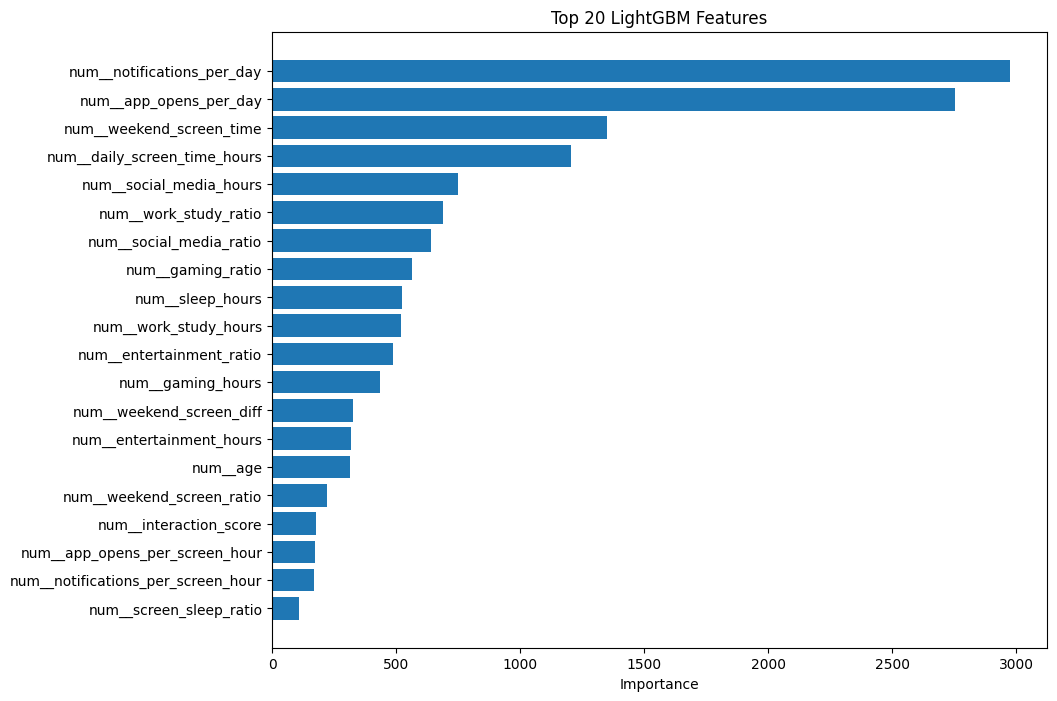

In [209]:
top_features = importance.head(20).sort_values(
    "importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 20 LightGBM Features")
plt.xlabel("Importance")
plt.show()

In [210]:
engineered_keywords = [
    "entertainment",
    "ratio",
    "interaction",
    "weekend_screen_diff",
    "app_opens_per_screen_hour",
    "notifications_per_screen_hour"
]

importance[
    importance["feature"].str.contains(
        "|".join(engineered_keywords),
        case=False,
        regex=True
    )
].sort_values(
    "importance",
    ascending=False
)

,feature,importance
13,num__work_study_ratio,688
11,num__social_media_ratio,640
12,num__gaming_ratio,564
10,num__entertainment_ratio,488
16,num__weekend_screen_diff,326
9,num__entertainment_hours,320
17,num__weekend_screen_ratio,220
20,num__interaction_score,176
18,num__app_opens_per_screen_hour,173
19,num__notifications_per_screen_hour,167


In [211]:
lgb_train_pred = lgb_model.predict_proba(X_train)[:, 1]

print(
    "Train AUC:",
    roc_auc_score(y_train, lgb_train_pred)
)

print(
    "Validation AUC:",
    lgb_valid_auc
)

Train AUC: 0.9637544721196323
Validation AUC: 0.9605579431351496


In [212]:
lgb = lgb_model.named_steps["model"]

feature_names = (
    lgb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": lgb.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(importance.head(20))

                               feature  importance
6           num__notifications_per_day        2976
7               num__app_opens_per_day        2754
8             num__weekend_screen_time        1349
1         num__daily_screen_time_hours        1205
2              num__social_media_hours         749
13               num__work_study_ratio         688
11             num__social_media_ratio         640
12                   num__gaming_ratio         564
5                     num__sleep_hours         522
4                num__work_study_hours         518
10            num__entertainment_ratio         488
3                    num__gaming_hours         436
16            num__weekend_screen_diff         326
9             num__entertainment_hours         320
0                             num__age         314
17           num__weekend_screen_ratio         220
20              num__interaction_score         176
18      num__app_opens_per_screen_hour         173
19  num__notifications_per_scre

In [213]:
def train_lgbm(params):
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LGBMClassifier(
                objective="binary",
                random_state=42,
                n_jobs=-1,
                verbosity=-1,
                **params
            ))
        ]
    )

    model.fit(X_train, y_train)

    pred = model.predict_proba(X_valid)[:, 1]

    score = roc_auc_score(y_valid, pred)

    return model, score

In [214]:
leaf_results = []

for leaves in [15, 31, 50, 70]:

    params = {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": leaves,
        "max_depth": -1,
        "min_child_samples": 50,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }

    model, score = train_lgbm(params)

    leaf_results.append({
        "num_leaves": leaves,
        "auc": score
    })

    print(
        f"num_leaves={leaves} → AUC={score:.6f}"
    )

num_leaves=15 → AUC=0.957227
num_leaves=31 → AUC=0.960558
num_leaves=50 → AUC=0.961700
num_leaves=70 → AUC=0.962214


In [215]:
leaf_results = []

for leaves in [15, 31, 50, 70]:

    params = {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": leaves,
        "max_depth": -1,
        "min_child_samples": 50,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }

    model, score = train_lgbm(params)

    leaf_results.append({
        "num_leaves": leaves,
        "auc": score
    })

    print(f"num_leaves={leaves} → AUC={score:.6f}")

num_leaves=15 → AUC=0.957227
num_leaves=31 → AUC=0.960558
num_leaves=50 → AUC=0.961700
num_leaves=70 → AUC=0.962214


In [216]:
leaf_results_2 = []

for leaves in [70, 100, 150]:

    params = {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": leaves,
        "max_depth": -1,
        "min_child_samples": 50,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }

    model, score = train_lgbm(params)

    leaf_results_2.append({
        "num_leaves": leaves,
        "auc": score
    })

    print(f"num_leaves={leaves} → AUC={score:.6f}")

num_leaves=70 → AUC=0.962214
num_leaves=100 → AUC=0.962531
num_leaves=150 → AUC=0.962761


In [217]:
num_leaves = 150

In [218]:
child_results = []

for min_child in [20, 50, 100, 200, 300]:

    params = {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 150,
        "max_depth": -1,
        "min_child_samples": min_child,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }

    model, score = train_lgbm(params)

    child_results.append({
        "min_child_samples": min_child,
        "auc": score
    })

    print(
        f"min_child_samples={min_child} "
        f"→ AUC={score:.6f}"
    )

min_child_samples=20 → AUC=0.962655
min_child_samples=50 → AUC=0.962761
min_child_samples=100 → AUC=0.962785
min_child_samples=200 → AUC=0.962910
min_child_samples=300 → AUC=0.963023


In [219]:
best_lgb_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 150,
    "max_depth": -1,
    "min_child_samples": 300,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}

In [220]:
final_lgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(**best_lgb_params))
    ]
)

In [221]:
X
y

,addicted_label
0,1
1,0
2,0
3,1
4,1
...,...
691364,1
691365,1
691366,1
691367,1


In [222]:
final_lgb_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['age',
                                                   'daily_screen_time_hours',
                                                   'social_media_hours',
                                                   'gaming_hours',
                                                   'work_study_hours',
                                                   'sleep_hours',
                                                   'notifications_per_day',
                                                   'app_opens_per_day',
                                                   'weekend_screen_time',
                                                   'entertainment_hours',
                                                   'entertainment_ratio',
                                                   'social_media_ratio',
                                                   'gaming_ratio...
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'stress_level',
                                                   'academic_work_impact',
                                                   'age_group'])])),
                ('model',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05,
                                min_child_samples=300, n_estimators=500,
                                n_jobs=-1, num_leaves=150, objective='binary',
                                random_state=42, subsample=0.8,
                                verbosity=-1))])

In [223]:
test_pred = final_lgb_model.predict_proba(
    X_test
)[:, 1]

In [224]:
print(test_pred[:10])
print(test_pred.min())
print(test_pred.max())

[0.99925866 0.9489489  0.96698641 0.986202   0.99687784 0.93970389
 0.87661061 0.54540349 0.98273296 0.33702536]
0.0003759839514514283
0.9999991295462313


In [225]:
submission = pd.DataFrame({
    "id": test["id"],
    "addicted_label": test_pred
})

In [226]:
print(submission.head())
print(submission.shape)

       id  addicted_label
0  691369        0.999259
1  691370        0.948949
2  691371        0.966986
3  691372        0.986202
4  691373        0.996878
(296302, 2)


In [227]:
print("Submission rows:", len(submission))
print("Test rows:", len(test))

print("Missing predictions:",
      submission["addicted_label"].isna().sum())

print("ID match:",
      submission["id"].equals(test["id"]))

Submission rows: 296302
Test rows: 296302
Missing predictions: 0
ID match: True


In [228]:
submission.to_csv(
    "submission_v1.csv",
    index=False
)

In [229]:
print(submission.head(10))

       id  addicted_label
0  691369        0.999259
1  691370        0.948949
2  691371        0.966986
3  691372        0.986202
4  691373        0.996878
5  691374        0.939704
6  691375        0.876611
7  691376        0.545403
8  691377        0.982733
9  691378        0.337025


In [230]:
# Best parameters we found so far
best_lgb_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 150,
    "max_depth": -1,
    "min_child_samples": 300,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}

# Final model
final_lgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(**best_lgb_params))
    ]
)

# Train on ALL training data
final_lgb_model.fit(X, y)

# Predict probabilities for test
test_pred = final_lgb_model.predict_proba(X_test)[:, 1]

# Create submission
submission = pd.DataFrame({
    "id": test["id"],
    "addicted_label": test_pred
})

# Save
submission.to_csv("submission_v1.csv", index=False)

print(submission.head())
print("Shape:", submission.shape)

       id  addicted_label
0  691369        0.999259
1  691370        0.948949
2  691371        0.966986
3  691372        0.986202
4  691373        0.996878
Shape: (296302, 2)


In [231]:
learning_rates = [0.02, 0.03, 0.05]
n_estimators = [500, 800, 1200]

In [232]:
configs = [
    (0.03, 800),
    (0.03, 1200),
    (0.05, 500),
    (0.05, 800),
]

In [233]:
for lr, n_est in configs:

    params = {
        "n_estimators": n_est,
        "learning_rate": lr,
        "num_leaves": 150,
        "max_depth": -1,
        "min_child_samples": 300,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }

    model, score = train_lgbm(params)

    print(
        f"learning_rate={lr}, "
        f"n_estimators={n_est} "
        f"→ AUC={score:.6f}"
    )

learning_rate=0.03, n_estimators=800 → AUC=0.963166
learning_rate=0.03, n_estimators=1200 → AUC=0.963264
learning_rate=0.05, n_estimators=500 → AUC=0.963023
learning_rate=0.05, n_estimators=800 → AUC=0.963141


In [234]:
subsample = 0.8
colsample_bytree = 0.8

In [235]:
configs = [
    (0.7, 0.7),
    (0.8, 0.8),
    (0.9, 0.9),
    (1.0, 1.0),
]

In [236]:
sampling_results = []

for subsample, colsample in configs:

    params = {
        "n_estimators": 1200,
        "learning_rate": 0.03,
        "num_leaves": 150,
        "max_depth": -1,
        "min_child_samples": 300,
        "subsample": subsample,
        "colsample_bytree": colsample
    }

    model, score = train_lgbm(params)

    sampling_results.append({
        "subsample": subsample,
        "colsample_bytree": colsample,
        "auc": score
    })

    print(
        f"subsample={subsample}, "
        f"colsample={colsample} "
        f"→ AUC={score:.6f}"
    )

subsample=0.7, colsample=0.7 → AUC=0.963364
subsample=0.8, colsample=0.8 → AUC=0.963264
subsample=0.9, colsample=0.9 → AUC=0.963253
subsample=1.0, colsample=1.0 → AUC=0.963054


In [237]:
base_params = {
    "n_estimators": 1200,
    "learning_rate": 0.03,
    "num_leaves": 150,
    "max_depth": -1,
    "min_child_samples": 300,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

In [238]:
lambda_results = []

for reg_lambda in [0, 0.1, 0.5, 1, 2, 5]:

    params = {
        **base_params,
        "reg_lambda": reg_lambda
    }

    model, score = train_lgbm(params)

    lambda_results.append({
        "reg_lambda": reg_lambda,
        "auc": score
    })

    print(
        f"reg_lambda={reg_lambda} "
        f"→ AUC={score:.6f}"
    )

reg_lambda=0 → AUC=0.963264
reg_lambda=0.1 → AUC=0.963228
reg_lambda=0.5 → AUC=0.963300
reg_lambda=1 → AUC=0.963324
reg_lambda=2 → AUC=0.963312
reg_lambda=5 → AUC=0.963346


In [240]:
alpha_results = []

best_lambda = 5  # put the best value here

for reg_alpha in [0, 0.01, 0.05, 0.1, 0.5, 1]:

    params = {
        **base_params,
        "reg_lambda": best_lambda,
        "reg_alpha": reg_alpha
    }

    model, score = train_lgbm(params)

    alpha_results.append({
        "reg_alpha": reg_alpha,
        "auc": score
    })

    print(
        f"reg_alpha={reg_alpha} "
        f"→ AUC={score:.6f}"
    )

reg_alpha=0 → AUC=0.963346
reg_alpha=0.01 → AUC=0.963408
reg_alpha=0.05 → AUC=0.963421
reg_alpha=0.1 → AUC=0.963419
reg_alpha=0.5 → AUC=0.963370
reg_alpha=1 → AUC=0.963509


In [241]:
best_params = {
    "n_estimators": 1200,
    "learning_rate": 0.03,
    "num_leaves": 150,
    "max_depth": -1,
    "min_child_samples": 300,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 1,
    "reg_lambda": 5,
    "objective": "binary",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}

In [242]:
final_lgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(**best_params))
    ]
)

In [244]:
print("Training final LightGBM...")

final_lgb_model.fit(X, y)

print("Training completed!")

Training final LightGBM...
Training completed!


In [245]:
test_pred_v2 = final_lgb_model.predict_proba(X_test)[:, 1]

In [246]:
print("First 10 predictions:")
print(test_pred_v2[:10])

print("\nMinimum:", test_pred_v2.min())
print("Maximum:", test_pred_v2.max())

First 10 predictions:
[0.99918    0.95182929 0.95630831 0.9905768  0.99625477 0.94329084
 0.87517313 0.59048983 0.98616539 0.32417087]

Minimum: 0.0003519774841397065
Maximum: 0.9999980609346683


In [247]:
submission_v2 = pd.DataFrame({
    "id": test["id"],
    "addicted_label": test_pred_v2
})

In [248]:
print(submission_v2.head(10))
print("\nShape:", submission_v2.shape)

       id  addicted_label
0  691369        0.999180
1  691370        0.951829
2  691371        0.956308
3  691372        0.990577
4  691373        0.996255
5  691374        0.943291
6  691375        0.875173
7  691376        0.590490
8  691377        0.986165
9  691378        0.324171

Shape: (296302, 2)


In [249]:
print("Rows:", len(submission_v2))
print("Expected:", len(test))

print("\nColumns:")
print(submission_v2.columns.tolist())

print("\nMissing values:")
print(submission_v2.isnull().sum())

print("\nID matches test:",
      submission_v2["id"].equals(test["id"]))

print("\nPrediction range:")
print(
    submission_v2["addicted_label"].min(),
    submission_v2["addicted_label"].max()
)

Rows: 296302
Expected: 296302

Columns:
['id', 'addicted_label']

Missing values:
id                0
addicted_label    0
dtype: int64

ID matches test: True

Prediction range:
0.0003519774841397065 0.9999980609346683


In [250]:
submission_v2.to_csv(
    "submission_v2.csv",
    index=False
)

print("Saved: submission_v2.csv")

Saved: submission_v2.csv


In [251]:
xgb_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1
}

In [252]:
final_xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(**xgb_params))
    ]
)

In [253]:
print("Training final XGBoost...")

final_xgb_model.fit(X, y)

print("XGBoost training completed.")

Training final XGBoost...
XGBoost training completed.


In [254]:
xgb_test_pred = final_xgb_model.predict_proba(
    X_test
)[:, 1]

In [255]:
lgb_test_pred = test_pred_v2

In [256]:

correlation = np.corrcoef(
    lgb_test_pred,
    xgb_test_pred
)[0, 1]

print("Prediction correlation:", correlation)

Prediction correlation: 0.9870080139584798


In [257]:
blend_predictions = {}

for lgb_weight in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:

    xgb_weight = 1 - lgb_weight

    blend_predictions[lgb_weight] = (
        lgb_weight * lgb_test_pred
        + xgb_weight * xgb_test_pred
    )

    print(
        f"LightGBM={lgb_weight:.2f}, "
        f"XGBoost={xgb_weight:.2f}"
    )

LightGBM=0.50, XGBoost=0.50
LightGBM=0.60, XGBoost=0.40
LightGBM=0.70, XGBoost=0.30
LightGBM=0.80, XGBoost=0.20
LightGBM=0.90, XGBoost=0.10
LightGBM=0.95, XGBoost=0.05


In [258]:
best_lgb_validation_model, _ = train_lgbm({
    "n_estimators": 1200,
    "learning_rate": 0.03,
    "num_leaves": 150,
    "max_depth": -1,
    "min_child_samples": 300,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 1,
    "reg_lambda": 5
})

In [259]:
lgb_val_pred = best_lgb_validation_model.predict_proba(
    X_valid
)[:, 1]

In [260]:
xgb_val_pred = xgb_model.predict_proba(
    X_valid
)[:, 1]

In [261]:
for lgb_weight in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:

    xgb_weight = 1 - lgb_weight

    blend_pred = (
        lgb_weight * lgb_val_pred
        + xgb_weight * xgb_val_pred
    )

    score = roc_auc_score(
        y_valid,
        blend_pred
    )

    print(
        f"LGB={lgb_weight:.2f}, "
        f"XGB={xgb_weight:.2f} "
        f"→ AUC={score:.6f}"
    )

LGB=0.50, XGB=0.50 → AUC=0.962474
LGB=0.60, XGB=0.40 → AUC=0.962837
LGB=0.70, XGB=0.30 → AUC=0.963128
LGB=0.80, XGB=0.20 → AUC=0.963349
LGB=0.90, XGB=0.10 → AUC=0.963503
LGB=0.95, XGB=0.05 → AUC=0.963556


In [262]:
best_params = {
    "n_estimators": 1200,
    "learning_rate": 0.03,
    "num_leaves": 150,
    "max_depth": -1,
    "min_child_samples": 300,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 1,
    "reg_lambda": 5,
    "objective": "binary",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}

In [264]:
from sklearn.model_selection import StratifiedKFold

In [265]:
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [266]:
import numpy as np

oof_pred = np.zeros(len(X))
test_pred_cv = np.zeros(len(X_test))

for fold, (train_idx, valid_idx) in enumerate(
    skf.split(X, y), 1
):

    print(f"\n========== FOLD {fold} ==========")

    X_tr = X.iloc[train_idx]
    X_va = X.iloc[valid_idx]

    y_tr = y.iloc[train_idx]
    y_va = y.iloc[valid_idx]

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LGBMClassifier(**best_params))
        ]
    )

    model.fit(X_tr, y_tr)

    # Validation / OOF prediction
    oof_pred[valid_idx] = model.predict_proba(
        X_va
    )[:, 1]

    # Test prediction
    test_pred_cv += (
        model.predict_proba(X_test)[:, 1] / 3
    )

    fold_auc = roc_auc_score(
        y_va,
        oof_pred[valid_idx]
    )

    print(f"Fold {fold} AUC: {fold_auc:.6f}")


========== FOLD 1 ==========
Fold 1 AUC: 0.963209

========== FOLD 2 ==========
Fold 2 AUC: 0.964197

========== FOLD 3 ==========
Fold 3 AUC: 0.964064


In [267]:
cv_auc = roc_auc_score(
    y,
    oof_pred
)

print("\n3-Fold CV ROC-AUC:", cv_auc)


3-Fold CV ROC-AUC: 0.96382239685979


In [268]:
submission_v3 = pd.DataFrame({
    "id": test["id"],
    "addicted_label": test_pred_cv
})

In [269]:
print(submission_v3.head(10))
print("\nShape:", submission_v3.shape)

print("\nMissing:")
print(submission_v3.isnull().sum())

print("\nID matches:")
print(submission_v3["id"].equals(test["id"]))

print("\nPrediction range:")
print(
    submission_v3["addicted_label"].min(),
    submission_v3["addicted_label"].max()
)

       id  addicted_label
0  691369        0.999097
1  691370        0.950192
2  691371        0.964203
3  691372        0.990849
4  691373        0.996662
5  691374        0.928182
6  691375        0.829424
7  691376        0.534400
8  691377        0.986609
9  691378        0.329621

Shape: (296302, 2)

Missing:
id                0
addicted_label    0
dtype: int64

ID matches:
True

Prediction range:
0.0004936223134315869 0.9999966968786127


In [270]:
submission_v3.to_csv(
    "submission_v3.csv",
    index=False
)

print("submission_v3.csv created!")

submission_v3.csv created!
